In [36]:
import os, pathlib, mlflow

# Racine du projet = parent si le notebook est dans ./notebook/, sinon cwd
ROOT = pathlib.Path.cwd()
MLRUNS_DIR = (ROOT.parent / "mlruns").resolve() if ROOT.name.lower() == "notebook" else (ROOT / "mlruns").resolve()
os.makedirs(MLRUNS_DIR, exist_ok=True)

mlflow.set_tracking_uri(f"file:{MLRUNS_DIR.as_posix()}")
mlflow.set_experiment("dev_models_loan")  # un seul nom d'expérience pour tout

print("Tracking URI ->", mlflow.get_tracking_uri())
print("MLRUNS_DIR   ->", MLRUNS_DIR)


2025/10/18 09:47:51 INFO mlflow.tracking.fluent: Experiment with name 'dev_models_loan' does not exist. Creating a new experiment.


Tracking URI -> file:C:/Users/kjoub/Documents/Formation_Data/DU/MLOps/Projet_LOAN/dev_models_loan/mlruns
MLRUNS_DIR   -> C:\Users\kjoub\Documents\Formation_Data\DU\MLOps\Projet_LOAN\dev_models_loan\mlruns


In [37]:
# Test de log simple
with mlflow.start_run(run_name="smoke_test"):
    mlflow.log_param("ping", 1)
    mlflow.log_metric("pong", 0.123)
print("OK")

OK


In [38]:
# EDA & Modélisation - Notebook principal

import mlflow
import mlflow.sklearn
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools, json, os, tempfile

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", None)
SEED = 42
np.random.seed(SEED)

# Dossiers
DATA_PATH = os.path.join("C:\\Users\\kjoub\\Documents\\Formation_Data\\DU\\MLOps\\Projet_LOAN\\dev_models_loan\\data", "Loan_Data.csv")
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)


In [39]:
df = pd.read_csv(DATA_PATH)
print(df.head())
print(df.info())


   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 

Vérifier et corriger les types de colonnes

In [40]:
# Colonnes attendues
expected_cols = [
    "customer_id",
    "credit_lines_outstanding",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "income",
    "years_employed",
    "fico_score",
    "default",
]

missing = set(expected_cols) - set(df.columns)
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

# Forcer types
df["customer_id"] = df["customer_id"].astype(str)

numeric_cols = [c for c in df.columns if c != "customer_id"]

for c in numeric_cols:
    # Convertit en numérique, remplace non numériques par NaN puis imput simple (médiane)
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Rapport sur NaN
na_report = df[numeric_cols].isna().sum().sort_values(ascending=False)
print("Valeurs manquantes après coercition:\n", na_report)

# Imputation médiane pour simplicité
for c in numeric_cols:
    med = df[c].median()
    df[c] = df[c].fillna(med)

# Vérification finale
print(df.dtypes)


Valeurs manquantes après coercition:
 credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64
customer_id                  object
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object


EDA rapide

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,8153374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,NaN,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,NaN,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,NaN,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,NaN,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,NaN,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000


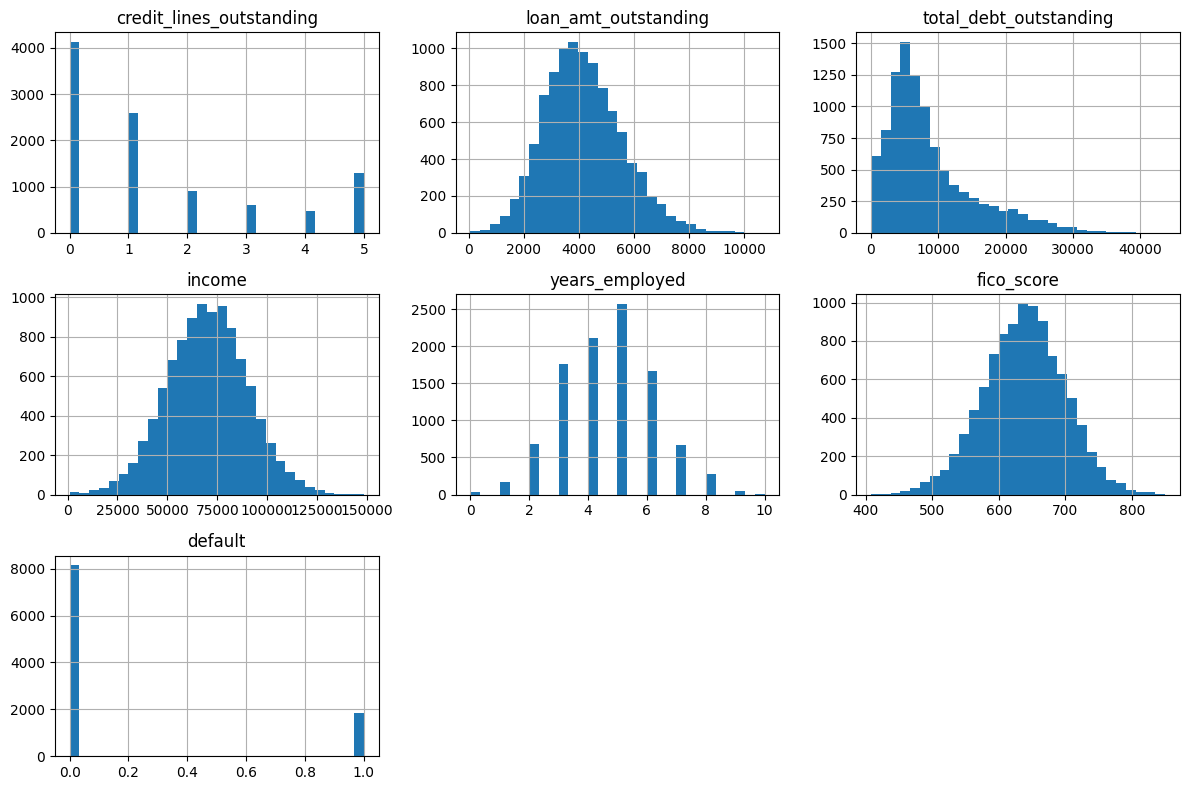

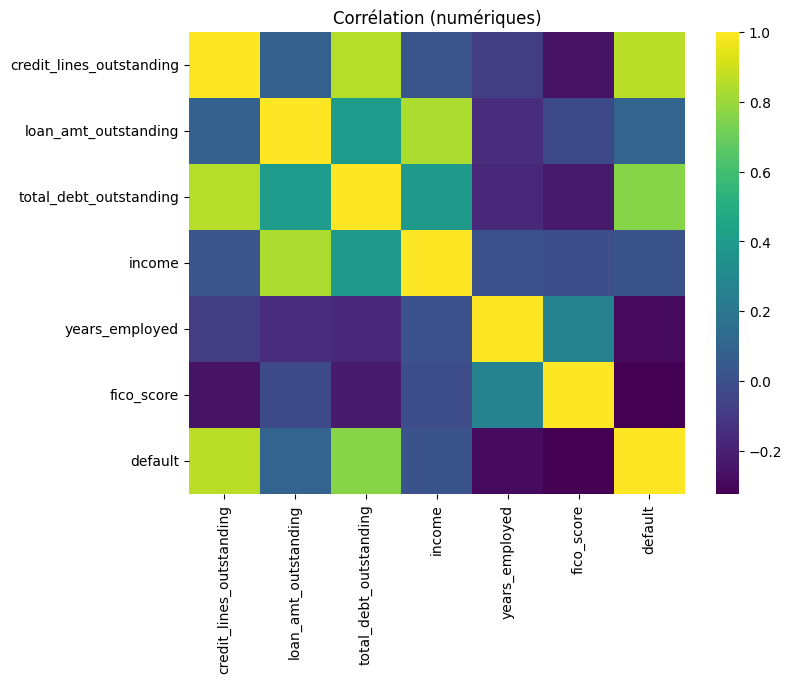

Répartition 'default':
default
0    0.815
1    0.185
Name: proportion, dtype: float64


In [41]:
display(df.describe(include="all"))

# Histogrammes des features numériques
_ = df[numeric_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Matrice de corrélation
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="viridis")
plt.title("Corrélation (numériques)")
plt.show()

# Répartition de la cible
print("Répartition 'default':")
print(df["default"].value_counts(normalize=True).round(3))


Split + Features

In [42]:
ID_COL = "customer_id"
TARGET = "default"

X = df.drop(columns=[ID_COL, TARGET])
y = df[TARGET].astype(int)  # s'assurer binaire 0/1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3))


(8000, 6) (2000, 6) 0.185 0.185


Modèle 1 — Decision Tree

Decision Tree — classification report
              precision    recall  f1-score   support

           0     0.9969    0.9969    0.9969      1630
           1     0.9865    0.9865    0.9865       370

    accuracy                         0.9950      2000
   macro avg     0.9917    0.9917    0.9917      2000
weighted avg     0.9950    0.9950    0.9950      2000

AUC: 0.9917095009119549


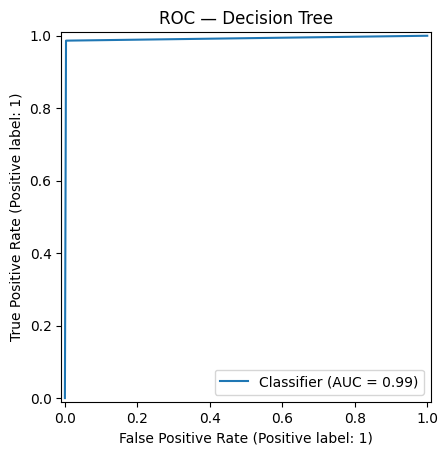

Decision Tree logged in MLflow.


c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


In [43]:
# Decision Tree

dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    random_state=SEED
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]
auc_dt = roc_auc_score(y_test, y_proba_dt)

print("Decision Tree — classification report")
print(classification_report(y_test, y_pred_dt, digits=4))
print("AUC:", auc_dt)

RocCurveDisplay.from_predictions(y_test, y_proba_dt)
plt.title("ROC — Decision Tree")
plt.show()

# Log Decision Tree
with mlflow.start_run(run_name="DecisionTree"):
    mlflow.log_param("max_depth", None)
    mlflow.log_param("min_samples_split", 2)
    mlflow.log_metric("auc", float(roc_auc_score(y_test, y_proba_dt)))
    mlflow.sklearn.log_model(dt, artifact_path="model")
print("Decision Tree logged in MLflow.")

Modèle 2 — Random Forest

In [44]:
# Random Forest avec recherche d'hyperparamètres et tracking MLflow
param_grid = {
    "n_estimators": [100, 300, 600],
    "max_depth": [None, 6, 12],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

def iter_grid(grid):
    keys = list(grid.keys())
    for values in itertools.product(*[grid[k] for k in keys]):
        yield dict(zip(keys, values))

results = []
best_auc = -1.0
best_model = None
best_params = None

# Boucle des essais avec tracking MLflow
for params in iter_grid(param_grid):
    rf = RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1,
        **params
    )
    rf.fit(X_train, y_train)
    y_proba = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    # Log du run pour CETTE combinaison
    run_name = f"RF_ne{params['n_estimators']}_d{params['max_depth']}_mss{params['min_samples_split']}_mf{params['max_features']}"
    with mlflow.start_run(run_name=run_name):
        # Hyperparams
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_param("random_state", SEED)
        mlflow.log_param("n_jobs", -1)

        # Métriques
        mlflow.log_metric("auc", float(auc))

        # Modèle (artefact)
        mlflow.sklearn.log_model(rf, artifact_path="model")

        # Ordre des features (utile pour l'inférence)
        feature_order = list(X.columns)
        tmp = tempfile.mkdtemp()
        meta = os.path.join(tmp, "feature_order.json")
        with open(meta, "w") as f:
            json.dump(feature_order, f)
        mlflow.log_artifact(meta, artifact_path="metadata")

    # Mémorise le résultat
    results.append({"auc": auc, **params})

    # Conservation du meilleur
    if auc > best_auc:
        best_auc = auc
        best_model = rf
        best_params = params

# Résumé local
df_results = pd.DataFrame(results).sort_values("auc", ascending=False)
display(df_results.head(10))
print("Best AUC:", round(best_auc, 4), "with params:", best_params)

# Entraînement/réutilisation du meilleur modèle
# Ici, best_model est déjà fit sur (X_train, y_train). On l’utilise pour produire les sorties finales.
rf_ref = best_model
y_pred_rf = rf_ref.predict(X_test)
y_proba_rf = rf_ref.predict_proba(X_test)[:, 1]

print("Random Forest — classification report (best)")
print(classification_report(y_test, y_pred_rf, digits=4))
print("AUC (best):", roc_auc_score(y_test, y_proba_rf))

# Run MLflow 'référence' pour le meilleur modèle
with mlflow.start_run(run_name="RandomForest_best"):
    # Re-log des meilleurs hyperparams et métriques
    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("random_state", SEED)
    mlflow.log_param("n_jobs", -1)

    mlflow.log_metric("auc", float(roc_auc_score(y_test, y_proba_rf)))

    # Log du modèle final
    mlflow.sklearn.log_model(rf_ref, artifact_path="model")

    # Ordre des features
    feature_order = list(X.columns)
    tmp = tempfile.mkdtemp()
    meta = os.path.join(tmp, "feature_order.json")
    with open(meta, "w") as f:
        json.dump(feature_order, f)
    mlflow.log_artifact(meta, artifact_path="metadata")


c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:15: UserWarning: Distutils was imported befo

,auc,n_estimators,max_depth,min_samples_split,max_features
13,0.999883,300,NaN,2,log2
12,0.999883,300,NaN,2,sqrt
21,0.999881,300,12.0,2,log2
20,0.999881,300,12.0,2,sqrt
22,0.999877,300,12.0,5,sqrt
23,0.999877,300,12.0,5,log2
15,0.999877,300,NaN,5,log2
14,0.999877,300,NaN,5,sqrt
33,0.999876,600,12.0,2,log2
32,0.999876,600,12.0,2,sqrt


Best AUC: 0.9999 with params: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'sqrt'}
Random Forest — classification report (best)
              precision    recall  f1-score   support

           0     0.9969    0.9982    0.9975      1630
           1     0.9918    0.9865    0.9892       370

    accuracy                         0.9960      2000
   macro avg     0.9944    0.9923    0.9934      2000
weighted avg     0.9960    0.9960    0.9960      2000

AUC (best): 0.9998831039628585


c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


Standardisation pour Logistic Regression

In [45]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Sauvegarde du scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))


['models\\scaler.joblib']

Modèle 3 — Logistic Regression

Logistic Regression — classification report
              precision    recall  f1-score   support

           0     0.9988    1.0000    0.9994      1630
           1     1.0000    0.9946    0.9973       370

    accuracy                         0.9990      2000
   macro avg     0.9994    0.9973    0.9983      2000
weighted avg     0.9990    0.9990    0.9990      2000

AUC: 0.9999883933012768


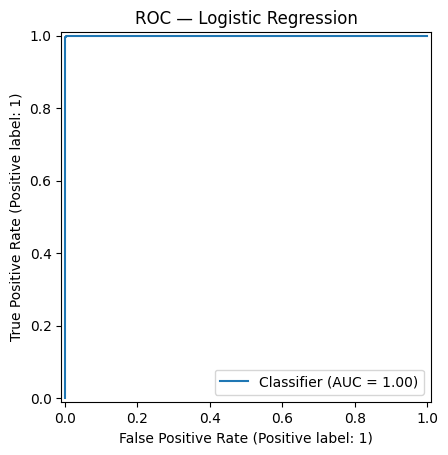

c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
c:\Users\kjoub\anaconda3\envs\envmlops\Lib\site-packages\_distutils_hack\__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
2025/10/18 09:59:28 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Logistic Regression logged in MLflow.


In [46]:
# Logistic Regression
logreg = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    n_jobs=-1
)
logreg.fit(X_train_std, y_train)

y_pred_lr = logreg.predict(X_test_std)
y_proba_lr = logreg.predict_proba(X_test_std)[:, 1]

print("Logistic Regression — classification report")
print(classification_report(y_test, y_pred_lr, digits=4))
print("AUC:", roc_auc_score(y_test, y_proba_lr))

disp = RocCurveDisplay.from_predictions(y_test, y_proba_lr)
plt.title("ROC — Logistic Regression")
plt.show()

joblib.dump(logreg, os.path.join(MODELS_DIR, "logreg.joblib"))

mlflow.set_experiment("dev_models_loan")  

with mlflow.start_run(run_name="LogisticRegression"):
    mlflow.log_param("solver", "lbfgs")
    mlflow.log_param("max_iter", 2000)
    mlflow.log_metric("auc", float(roc_auc_score(y_test, y_proba_lr)))
    mlflow.sklearn.log_model(logreg, artifact_path="model")
    mlflow.sklearn.log_model(scaler, artifact_path="scaler")
print("Logistic Regression logged in MLflow.")

Matrice de confusion comparée

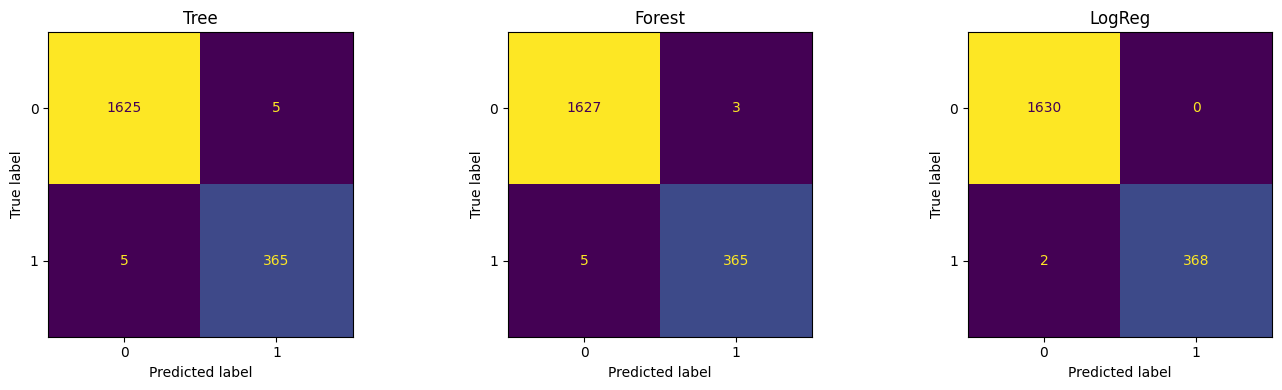

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, (name, y_pred) in zip(
    axes, 
    [("Tree", y_pred_dt), ("Forest", y_pred_rf), ("LogReg", y_pred_lr)]
):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


Tableau de synthèse des scores

In [48]:
metrics = pd.DataFrame({
    "model": ["DecisionTree", "RandomForest", "LogisticRegression"],
    "auc": [
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_lr),
    ]
})
display(metrics.sort_values("auc", ascending=False))
metrics.to_csv(os.path.join("models", "metrics.csv"), index=False)


,model,auc
2,LogisticRegression,0.999988
1,RandomForest,0.999883
0,DecisionTree,0.991710
